In [44]:
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


question 1

In [46]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


(38765, 3)

In [47]:
df["Member_number"].nunique()

3898

In [48]:
df["itemDescription"].nunique()

167

In [49]:
transactions = df.groupby(
    ["Member_number","Date"]
)["itemDescription"].apply(list)
transactions.head()

Member_number  Date      
1000           15-03-2015    [sausage, whole milk, semi-finished bread, yog...
               24-06-2014                    [whole milk, pastry, salty snack]
               24-07-2015                       [canned beer, misc. beverages]
               25-11-2015                          [sausage, hygiene articles]
               27-05-2015                           [soda, pickled vegetables]
Name: itemDescription, dtype: object

In [50]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
frequent_ap = apriori(
    basket,
    min_support=0.005,
    use_colnames=True
)
frequent_ap.head()
print(len(frequent_ap))

126


In [52]:
rules_ap = association_rules(
    frequent_ap,
    metric="confidence",
    min_threshold=0.1
)
rules_ap.head()
print("Frequent Itemsets:", len(frequent_ap))
print("Association Rules:", len(rules_ap))

Frequent Itemsets: 126
Association Rules: 19


In [53]:
rules_ap.sort_values(
    by="lift",
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
0,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
14,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
7,(newspapers),(whole milk),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
4,(domestic eggs),(whole milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
6,(frankfurter),(whole milk),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
11,(pork),(whole milk),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
10,(pip fruit),(whole milk),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
3,(citrus fruit),(whole milk),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
15,(shopping bags),(whole milk),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


In [54]:
frequent_fp = fpgrowth(
    basket,
    min_support=0.005,
    use_colnames=True
)

In [55]:
rules_fp = association_rules(
    frequent_fp,
    metric="confidence",
    min_threshold=0.1
)

In [56]:
print("Frequent Itemsets:", len(frequent_ap))
print("Association Rules:", len(rules_ap))

Frequent Itemsets: 126
Association Rules: 19


In [57]:
rules_fp.sort_values(
    by="lift",
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
14,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
16,(newspapers),(whole milk),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
15,(domestic eggs),(whole milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
5,(frankfurter),(whole milk),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
18,(pork),(whole milk),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
11,(pip fruit),(whole milk),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
17,(citrus fruit),(whole milk),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
12,(shopping bags),(whole milk),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


In [58]:
duplicate = df.sample(
    frac=0.05,
    random_state=42
)

In [59]:
df_duplicate = pd.concat(
    [df, duplicate],
    ignore_index=True
)
len(df)
len(df_duplicate)

40703

In [60]:
transactions_duplicate = (
    df_duplicate.groupby(["Member_number", "Date"])["itemDescription"]
    .apply(list)
    .tolist()
)

In [61]:
te2 = TransactionEncoder()

te_array2 = te2.fit(transactions_duplicate).transform(transactions_duplicate)

basket_duplicate = pd.DataFrame(
    te_array2,
    columns=te2.columns_
)

In [62]:
frequent_ap_duplicate = apriori(
    basket_duplicate,
    min_support=0.005,
    use_colnames=True
)

rules_ap_duplicate = association_rules(
    frequent_ap_duplicate,
    metric="confidence",
    min_threshold=0.1
)

print("Frequent Itemsets:", len(frequent_ap_duplicate))
print("Association Rules:", len(rules_ap_duplicate))

Frequent Itemsets: 126
Association Rules: 19


In [63]:
frequent_fp_duplicate = fpgrowth(
    basket_duplicate,
    min_support=0.005,
    use_colnames=True
)

rules_fp_duplicate = association_rules(
    frequent_fp_duplicate,
    metric="confidence",
    min_threshold=0.1
)

print("Frequent Itemsets:", len(frequent_fp_duplicate))
print("Association Rules:", len(rules_fp_duplicate))

Frequent Itemsets: 126
Association Rules: 19


In [64]:
rules_ap_duplicate.sort_values(
    by="lift",
    ascending=False
).head(10)
rules_fp_duplicate.sort_values(
    by="lift",
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
14,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
16,(newspapers),(whole milk),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
15,(domestic eggs),(whole milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
5,(frankfurter),(whole milk),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
18,(pork),(whole milk),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
11,(pip fruit),(whole milk),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
17,(citrus fruit),(whole milk),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
12,(shopping bags),(whole milk),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


In [65]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Apriori",
        "FP-Growth",
        "Apriori + Duplicate",
        "FP-Growth + Duplicate"
    ],
    "Frequent Itemsets": [
        len(frequent_ap),
        len(frequent_fp),
        len(frequent_ap_duplicate),
        len(frequent_fp_duplicate)
    ],
    "Association Rules": [
        len(rules_ap),
        len(rules_fp),
        len(rules_ap_duplicate),
        len(rules_fp_duplicate)
    ]
})

comparison

,Algorithm,Frequent Itemsets,Association Rules
0,Apriori,126,19
1,FP-Growth,126,19
2,Apriori + Duplicate,126,19
3,FP-Growth + Duplicate,126,19


question 4

In [66]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
print(df["Year"].value_counts().sort_index())


Year
2014    18277
2015    20488
Name: count, dtype: int64


In [67]:
print(df["Month"].value_counts().sort_index())

Month
1     3324
2     2997
3     3133
4     3260
5     3408
6     3264
7     3300
8     3496
9     3059
10    3261
11    3254
12    3009
Name: count, dtype: int64


In [68]:
print(df["Weekday"].value_counts())

Weekday
Thursday     5620
Friday       5562
Wednesday    5562
Tuesday      5558
Saturday     5551
Sunday       5530
Monday       5382
Name: count, dtype: int64


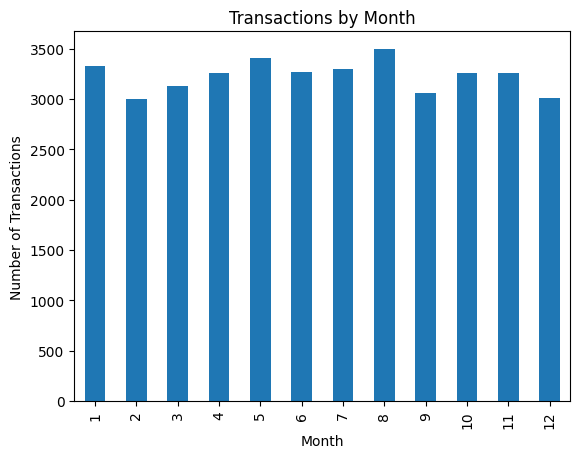

In [69]:
import matplotlib.pyplot as plt

df["Month"].value_counts().sort_index().plot(kind="bar")

plt.title("Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

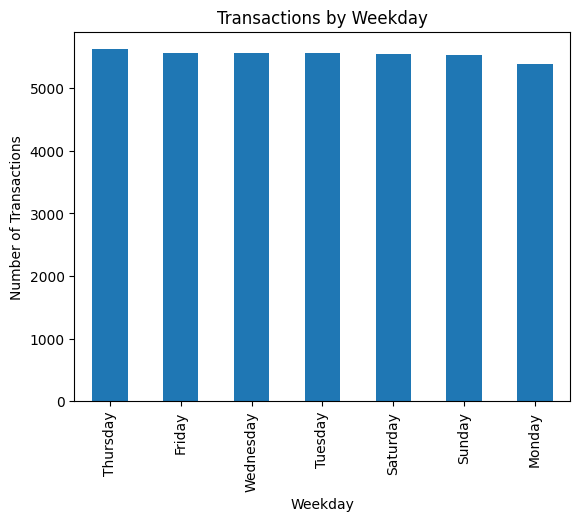

In [70]:
df["Weekday"].value_counts().plot(kind="bar")

plt.title("Transactions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Transactions")
plt.show()

question 5

In [71]:
customer_item = pd.crosstab(
    df["Member_number"],
    df["itemDescription"]
)

customer_item.head()

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,2,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(customer_item)

In [73]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_item["Cluster"] = kmeans.fit_predict(X)

In [74]:
customer_item["Cluster"].value_counts()

Cluster
1    2527
0    1339
2      20
3      12
Name: count, dtype: int64

In [75]:
cluster_summary = customer_item.groupby("Cluster").mean()

cluster_summary

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.023898,0.137416,0.007468,0.013443,0.000747,0.000747,0.055265,0.007468,0.199403,0.120986,...,0.036594,0.011949,0.123973,0.256161,0.005975,0.163555,0.085138,1.020164,0.530246,0.034354
1,0.011080,0.053819,0.004749,0.004353,0.000396,0.001187,0.018599,0.002770,0.096557,0.064108,...,0.012268,0.013455,0.043926,0.123862,0.000000,0.056589,0.024139,0.440839,0.243767,0.005540
2,0.000000,0.050000,0.000000,0.000000,0.050000,0.000000,0.050000,0.000000,0.150000,0.150000,...,0.000000,0.050000,0.050000,0.250000,0.000000,0.000000,0.000000,0.750000,0.300000,0.000000
3,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,...,0.000000,0.000000,0.166667,0.083333,0.000000,0.000000,0.083333,0.583333,0.166667,0.000000


In [76]:
for cluster in cluster_summary.index:
    print(f"\nCluster {cluster}")
    print(cluster_summary.loc[cluster].sort_values(ascending=False).head(10))


Cluster 0
itemDescription
whole milk          1.020164
other vegetables    0.775952
rolls/buns          0.631068
soda                0.592980
yogurt              0.530246
tropical fruit      0.415235
root vegetables     0.412995
sausage             0.412995
bottled water       0.365945
pastry              0.343540
Name: 0, dtype: float64

Cluster 1
itemDescription
whole milk          0.440839
rolls/buns          0.339137
other vegetables    0.332806
soda                0.280966
yogurt              0.243767
root vegetables     0.201029
tropical fruit      0.184804
bottled water       0.172932
citrus fruit        0.155125
sausage             0.143253
Name: 1, dtype: float64

Cluster 2
itemDescription
skin care           1.00
whole milk          0.75
other vegetables    0.55
rolls/buns          0.50
pip fruit           0.40
frankfurter         0.40
chicken             0.35
tropical fruit      0.35
margarine           0.35
root vegetables     0.35
Name: 2, dtype: float64

Cluster 3
itemDe

question6

In [77]:
top10 = rules_ap.sort_values(
    by="lift",
    ascending=False
).head(10).copy()

In [78]:
top10["Imbalance Ratio"] = (
    abs(
        top10["antecedent support"] -
        top10["consequent support"]
    )
    /
    (
        top10["antecedent support"] +
        top10["consequent support"] -
        top10["support"]
    )
)

In [79]:
top10[
    [
        "antecedents",
        "consequents",
        "lift",
        "kulczynski",
        "Imbalance Ratio"
    ]
]

,antecedents,consequents,lift,kulczynski,Imbalance Ratio
5,(frankfurter),(other vegetables),1.116150,0.089214,0.545140
0,(bottled beer),(whole milk),0.999330,0.101549,0.574301
14,(sausage),(whole milk),0.939663,0.102551,0.466156
7,(newspapers),(whole milk),0.913926,0.089939,0.622510
4,(domestic eggs),(whole milk),0.901341,0.087887,0.636844
6,(frankfurter),(whole milk),0.885388,0.086628,0.631099
11,(pork),(whole milk),0.855703,0.083437,0.635948
10,(pip fruit),(whole milk),0.854071,0.088387,0.543362
3,(citrus fruit),(whole milk),0.852259,0.089936,0.513930
15,(shopping bags),(whole milk),0.844887,0.086815,0.554027


## Chi Square and Silhouette Score

In [80]:
import scipy.stats as stats

item_columns = [col for col in customer_item.columns if col != 'Cluster']

chi_square_results = []

for item in item_columns:
    contingency_table = pd.crosstab(customer_item["Cluster"], customer_item[item])
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    chi_square_results.append({
        'Item': item,
        'Chi_Square_Stat': chi2,
        'P_value': p_value
    })

results_df = pd.DataFrame(chi_square_results)

significant_items = results_df[results_df['P_value'] < 0.05].sort_values(by='Chi_Square_Stat', ascending=False)

print("Items that have the greatest role in distinguishing clusters")
print(significant_items.head(15)) 

Items that have the greatest role in distinguishing clusters
                      Item  Chi_Square_Stat       P_value
38                   cream      3898.000000  0.000000e+00
134              skin care      3898.000000  0.000000e+00
164             whole milk       426.945742  1.485487e-81
102       other vegetables       346.307584  1.242954e-64
130                sausage       262.617105  2.154979e-51
165                 yogurt       212.558904  8.264306e-39
138                   soda       212.360711  9.083168e-39
64   fruit/vegetable juice       198.242728  7.736230e-38
105                 pastry       197.730639  9.586801e-36
156         tropical fruit       182.055939  1.614348e-32
20             canned beer       180.063617  4.914123e-34
11            bottled beer       171.506746  2.994998e-32
122             rolls/buns       167.812661  1.336839e-29
56             frankfurter       150.664787  6.422798e-28
12           bottled water       143.443969  1.206505e-24


In [81]:
from sklearn.metrics import silhouette_score

X = customer_item.drop('Cluster', axis=1)

labels = customer_item['Cluster']

silhouette_avg = silhouette_score(X, labels)

print(f"Silhouette Score: {silhouette_avg:.4f}")


Silhouette Score: 0.0227
